# Customer Segmentation via Clustering Algorithms

Comparative analysis of four clustering methods applied to credit card usage data.

**Dataset:** Credit Card Customer Data (Kaggle) — 8950 customers, 17 behavioral features

**Algorithms compared:** K-Means · DBSCAN · Agglomerative · OPTICS

**Evaluation:** Silhouette Score · Davies-Bouldin Index · Calinski-Harabasz Index

In [3]:
%pip install kneed

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering, OPTICS
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.neighbors import NearestNeighbors
from kneed import KneeLocator
import scipy.cluster.hierarchy as shc
import kagglehub
import os
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

COLORS = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
RANDOM_STATE = 42

In [50]:
def assign_noise_to_nearest(X, labels):
    labels = labels.copy()
    noise_mask = labels == -1
    if not noise_mask.any():
        return labels
    unique_clusters = np.unique(labels[~noise_mask])
    centroids = np.array([X[labels == c].mean(axis=0) for c in unique_clusters])
    nn = NearestNeighbors(n_neighbors=1).fit(centroids)
    _, idx = nn.kneighbors(X[noise_mask])
    labels[noise_mask] = unique_clusters[idx.ravel()]
    return labels

## 1. Data Loading & Preprocessing

In [51]:
path = kagglehub.dataset_download('arjunbhasin2013/ccdata')
csv_file = os.path.join(path, 'CC GENERAL.csv')
if not os.path.exists(csv_file):
    csv_file = os.path.join(path, 'CC_GENERAL.csv')

df = pd.read_csv(csv_file)
print(f'Shape: {df.shape}')
df.head()

Using Colab cache for faster access to the 'ccdata' dataset.
Shape: (8950, 18)


,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [52]:
print('Missing values per column:')
print(df.isnull().sum()[df.isnull().sum() > 0])
print(f'\nDuplicate rows: {df.duplicated().sum()}')
df.describe().T

Missing values per column:
CREDIT_LIMIT          1
MINIMUM_PAYMENTS    313
dtype: int64

Duplicate rows: 0


,count,mean,std,min,25%,50%,75%,max
BALANCE,8950.0,1564.474828,2081.531879,0.000000,128.281915,873.385231,2054.140036,19043.13856
BALANCE_FREQUENCY,8950.0,0.877271,0.236904,0.000000,0.888889,1.000000,1.000000,1.00000
PURCHASES,8950.0,1003.204834,2136.634782,0.000000,39.635000,361.280000,1110.130000,49039.57000
ONEOFF_PURCHASES,8950.0,592.437371,1659.887917,0.000000,0.000000,38.000000,577.405000,40761.25000
INSTALLMENTS_PURCHASES,8950.0,411.067645,904.338115,0.000000,0.000000,89.000000,468.637500,22500.00000
CASH_ADVANCE,8950.0,978.871112,2097.163877,0.000000,0.000000,0.000000,1113.821139,47137.21176
PURCHASES_FREQUENCY,8950.0,0.490351,0.401371,0.000000,0.083333,0.500000,0.916667,1.00000
ONEOFF_PURCHASES_FREQUENCY,8950.0,0.202458,0.298336,0.000000,0.000000,0.083333,0.300000,1.00000
PURCHASES_INSTALLMENTS_FREQUENCY,8950.0,0.364437,0.397448,0.000000,0.000000,0.166667,0.750000,1.00000
CASH_ADVANCE_FREQUENCY,8950.0,0.135144,0.200121,0.000000,0.000000,0.000000,0.222222,1.50000


Components to explain 95% variance: 12
NOTE: 2D PCA captures 47.61% of variance — used for visualization only. Clustering runs on all 17 features.


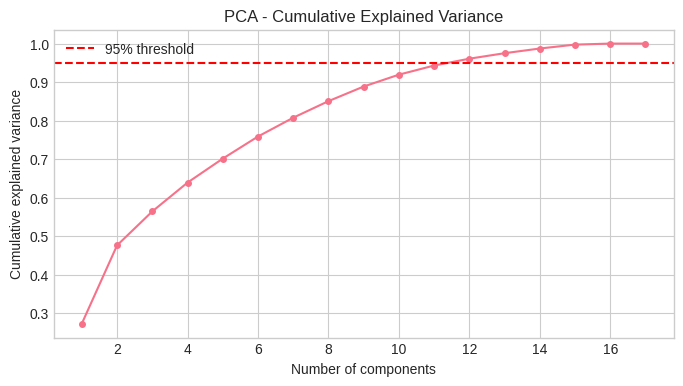

In [53]:
df_clean = df.drop('CUST_ID', axis=1, errors='ignore')
df_clean = df_clean.fillna(df_clean.median())

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clean)

# PCA used only for 2D visualization; all clustering and metrics run on the full scaled data
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_scaled)

cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n_components_95 = np.argmax(cumvar >= 0.95) + 1

pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca_2d.fit_transform(X_scaled)

print(f'Components to explain 95% variance: {n_components_95}')
print(f'NOTE: 2D PCA captures {pca_2d.explained_variance_ratio_.sum():.2%} of variance — used for visualization only. Clustering runs on all {X_scaled.shape[1]} features.')

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(cumvar)+1), cumvar, marker='o', markersize=4)
plt.axhline(0.95, color='red', linestyle='--', label='95% threshold')
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance')
plt.title('PCA - Cumulative Explained Variance')
plt.legend()
plt.show()

## 2. K-Means Clustering

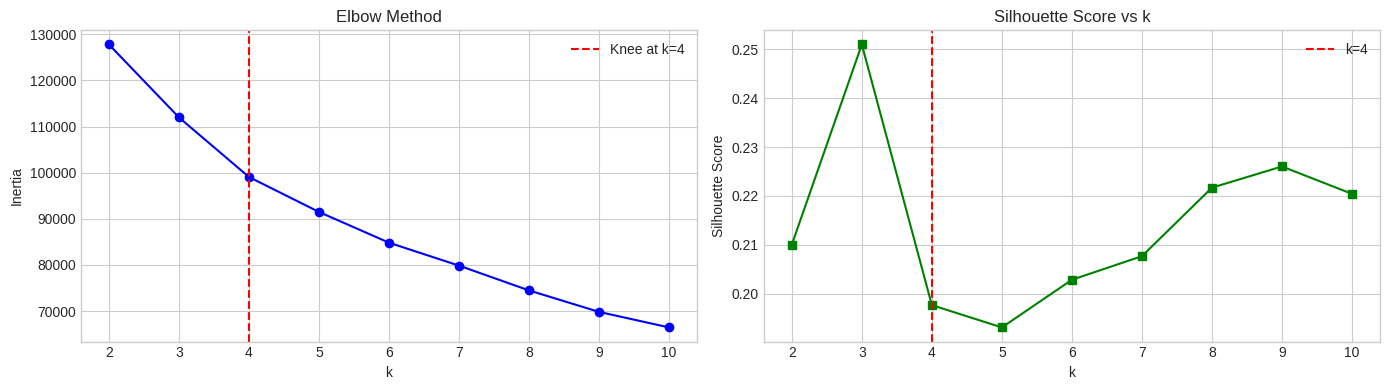

Optimal k (KneeLocator): 4


In [54]:
# Elbow method + Silhouette scores to select optimal k
K_range = range(2, 11)
inertias = []
silhouettes = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

# Automatic knee detection
kl = KneeLocator(list(K_range), inertias, curve='convex', direction='decreasing')
optimal_k = kl.knee if kl.knee else 4

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(K_range, inertias, 'bo-')
axes[0].axvline(optimal_k, color='red', linestyle='--', label=f'Knee at k={optimal_k}')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method')
axes[0].legend()

axes[1].plot(K_range, silhouettes, 'gs-')
axes[1].axvline(optimal_k, color='red', linestyle='--', label=f'k={optimal_k}')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score vs k')
axes[1].legend()

plt.tight_layout()
plt.show()
print(f'Optimal k (KneeLocator): {optimal_k}')

K-Means (k=4)
  Silhouette:         0.1977
  Davies-Bouldin:     1.5748
  Calinski-Harabasz:  1598.08
  Cluster sizes: [3977  409 1197 3367]


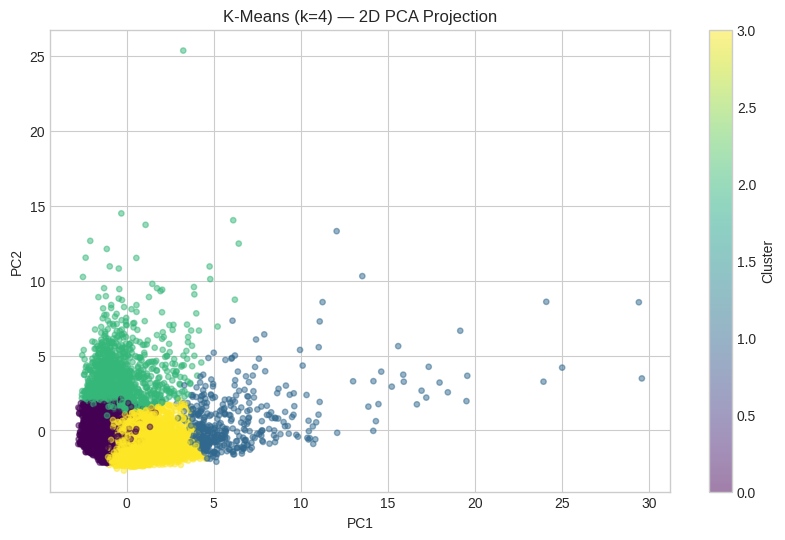

In [55]:
kmeans_final = KMeans(n_clusters=optimal_k, random_state=RANDOM_STATE, n_init=10)
labels_kmeans = kmeans_final.fit_predict(X_scaled)

km_sil = silhouette_score(X_scaled, labels_kmeans)
km_db  = davies_bouldin_score(X_scaled, labels_kmeans)
km_ch  = calinski_harabasz_score(X_scaled, labels_kmeans)

print(f'K-Means (k={optimal_k})')
print(f'  Silhouette:         {km_sil:.4f}')
print(f'  Davies-Bouldin:     {km_db:.4f}')
print(f'  Calinski-Harabasz:  {km_ch:.2f}')
print(f'  Cluster sizes: {np.bincount(labels_kmeans)}')

plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_kmeans, cmap='viridis', alpha=0.5, s=15)
plt.colorbar(scatter, label='Cluster')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title(f'K-Means (k={optimal_k}) — 2D PCA Projection')
plt.show()

## 3. DBSCAN

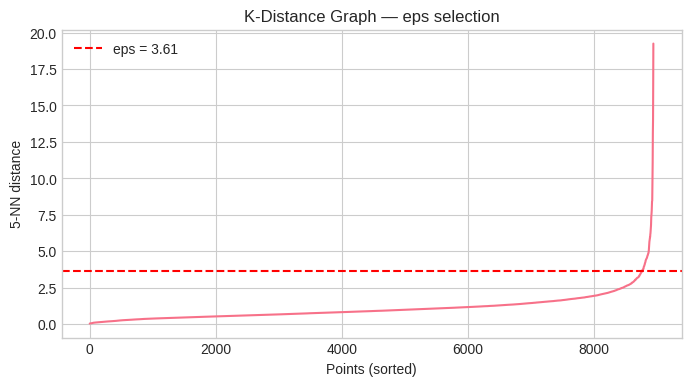

Suggested eps: 3.61


In [56]:
# K-distance plot to estimate eps: look for the 'elbow'
k_neighbors = 5
nn = NearestNeighbors(n_neighbors=k_neighbors)
nn.fit(X_scaled)
distances, _ = nn.kneighbors(X_scaled)
k_distances = np.sort(distances[:, k_neighbors - 1])

kl_eps = KneeLocator(range(len(k_distances)), k_distances, curve='convex', direction='increasing')
eps_auto = round(k_distances[kl_eps.knee], 2) if kl_eps.knee else 2.0

plt.figure(figsize=(8, 4))
plt.plot(k_distances)
plt.axhline(eps_auto, color='red', linestyle='--', label=f'eps = {eps_auto}')
plt.xlabel('Points (sorted)')
plt.ylabel(f'{k_neighbors}-NN distance')
plt.title('K-Distance Graph — eps selection')
plt.legend()
plt.show()
print(f'Suggested eps: {eps_auto}')

DBSCAN  eps=3.61, min_samples=5
  Clusters found: 1
  Noise points:   121 (1.4%)
  Consider adjusting eps or min_samples. eps_auto may be too large for this dataset.


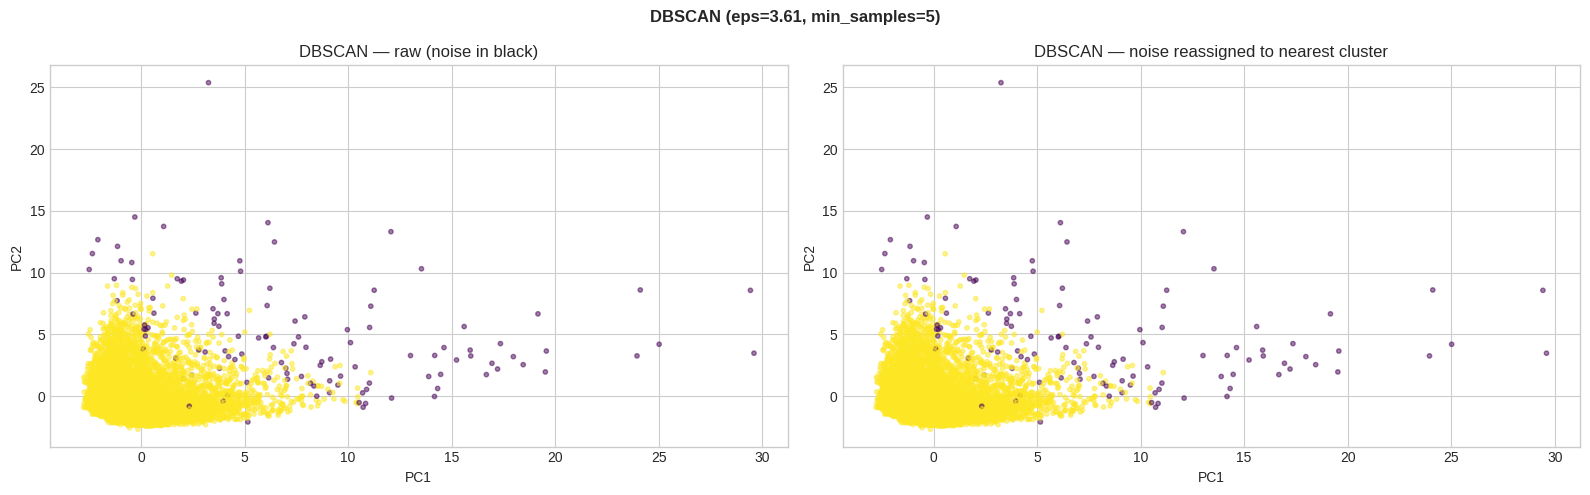

In [57]:
eps_val = eps_auto
min_samples_val = 5

dbscan = DBSCAN(eps=eps_val, min_samples=min_samples_val)
labels_dbscan_raw = dbscan.fit_predict(X_scaled)

n_clusters_db = len(set(labels_dbscan_raw)) - (1 if -1 in labels_dbscan_raw else 0)
n_noise_db = (labels_dbscan_raw == -1).sum()

print(f'DBSCAN  eps={eps_val}, min_samples={min_samples_val}')
print(f'  Clusters found: {n_clusters_db}')
print(f'  Noise points:   {n_noise_db} ({n_noise_db/len(labels_dbscan_raw)*100:.1f}%)')

# DBSCAN can degenerate to a single cluster on high-dimensional data depending on eps.
# When that happens, internal metrics are undefined.
# When valid clusters exist, noise is reassigned to the nearest centroid
# so all algorithms are evaluated on 100% of data points.
if n_clusters_db < 2:
    print('  WARNING: DBSCAN found fewer than 2 clusters. Metrics cannot be computed.')
    print('  Consider adjusting eps or min_samples. eps_auto may be too large for this dataset.')
    db_sil = db_db = db_ch = float('nan')
    labels_dbscan = labels_dbscan_raw
else:
    labels_dbscan = assign_noise_to_nearest(X_scaled, labels_dbscan_raw)
    db_sil = silhouette_score(X_scaled, labels_dbscan)
    db_db  = davies_bouldin_score(X_scaled, labels_dbscan)
    db_ch  = calinski_harabasz_score(X_scaled, labels_dbscan)
    print(f'  Silhouette (noise reassigned):        {db_sil:.4f}')
    print(f'  Davies-Bouldin (noise reassigned):    {db_db:.4f}')
    print(f'  Calinski-Harabasz (noise reassigned): {db_ch:.2f}')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=labels_dbscan_raw, cmap='viridis', alpha=0.5, s=10)
axes[0].set_title('DBSCAN — raw (noise in black)')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=labels_dbscan, cmap='viridis', alpha=0.5, s=10)
axes[1].set_title('DBSCAN — noise reassigned to nearest cluster')
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')
plt.suptitle(f'DBSCAN (eps={eps_val}, min_samples={min_samples_val})', fontweight='bold')
plt.tight_layout()
plt.show()

> **Note:** With the automatically selected eps, DBSCAN may collapse into a single cluster on this high-dimensional standardized dataset, making internal metrics undefined. This is expected behavior — it reflects DBSCAN's sensitivity to parameter tuning, not a code error.

## 4. Agglomerative Clustering

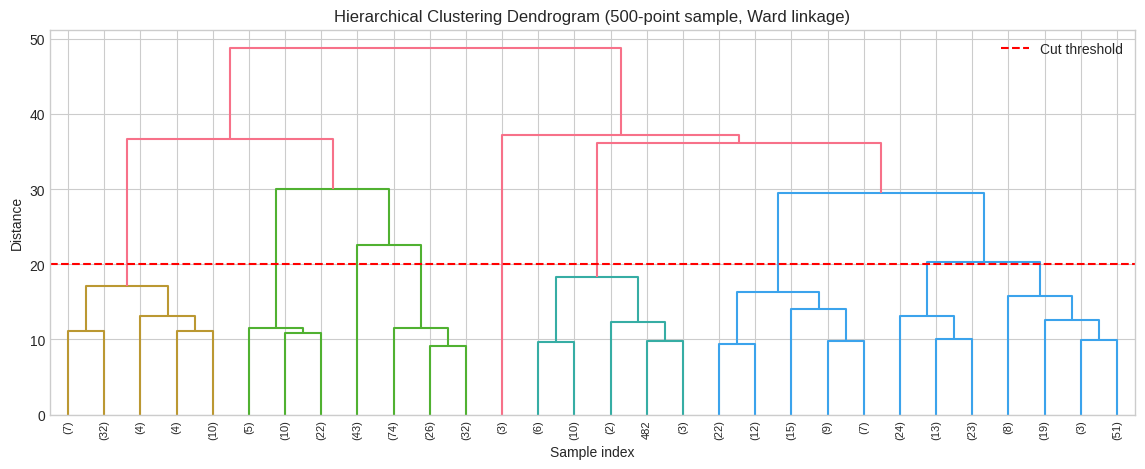

In [58]:
# Dendrogram on a subsample to keep it readable
sample_idx = np.random.RandomState(RANDOM_STATE).choice(len(X_scaled), 500, replace=False)
X_sample = X_scaled[sample_idx]

plt.figure(figsize=(14, 5))
linkage_matrix = shc.linkage(X_sample, method='ward')
shc.dendrogram(linkage_matrix, truncate_mode='lastp', p=30, leaf_rotation=90, leaf_font_size=8)
plt.axhline(y=20, color='red', linestyle='--', label='Cut threshold')
plt.title('Hierarchical Clustering Dendrogram (500-point sample, Ward linkage)')
plt.xlabel('Sample index')
plt.ylabel('Distance')
plt.legend()
plt.show()

Agglomerative (k=4, linkage=ward)
  Silhouette:         0.1598
  Davies-Bouldin:     1.7503
  Calinski-Harabasz:  1223.61
  Cluster sizes: [4875  300 1194 2581]


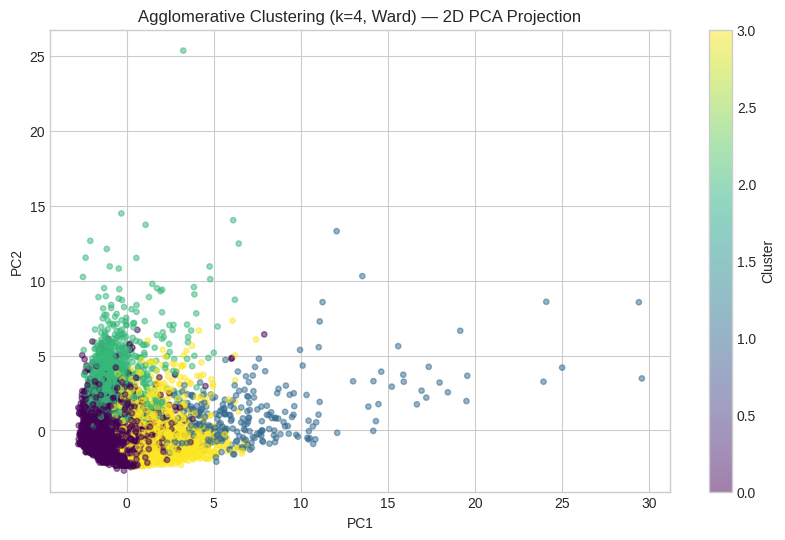

In [59]:
agg_model = AgglomerativeClustering(n_clusters=optimal_k, linkage='ward')
labels_agg = agg_model.fit_predict(X_scaled)

agg_sil = silhouette_score(X_scaled, labels_agg)
agg_db  = davies_bouldin_score(X_scaled, labels_agg)
agg_ch  = calinski_harabasz_score(X_scaled, labels_agg)

print(f'Agglomerative (k={optimal_k}, linkage=ward)')
print(f'  Silhouette:         {agg_sil:.4f}')
print(f'  Davies-Bouldin:     {agg_db:.4f}')
print(f'  Calinski-Harabasz:  {agg_ch:.2f}')
print(f'  Cluster sizes: {np.bincount(labels_agg)}')

plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_agg, cmap='viridis', alpha=0.5, s=15)
plt.colorbar(scatter, label='Cluster')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title(f'Agglomerative Clustering (k={optimal_k}, Ward) — 2D PCA Projection')
plt.show()

## 5. OPTICS

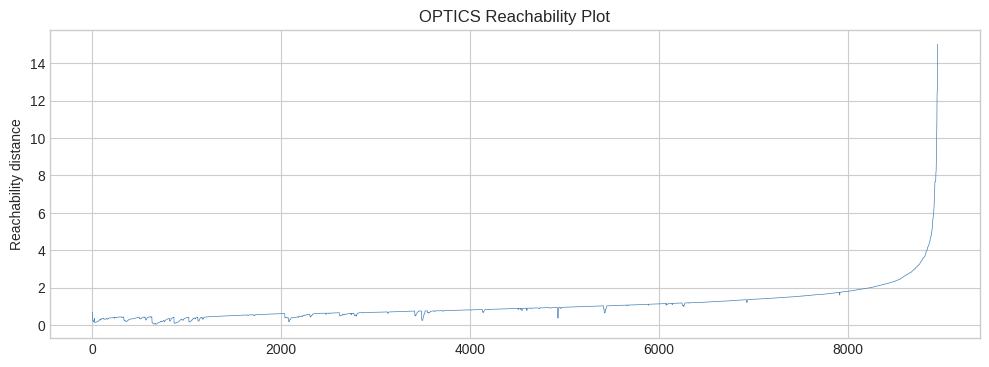

OPTICS  min_samples=10, xi=0.05
  Clusters found: 23
  Noise points:   8498 (94.9%)
  Silhouette (noise reassigned):        -0.0264
  Davies-Bouldin (noise reassigned):    2.1064
  Calinski-Harabasz (noise reassigned): 339.89


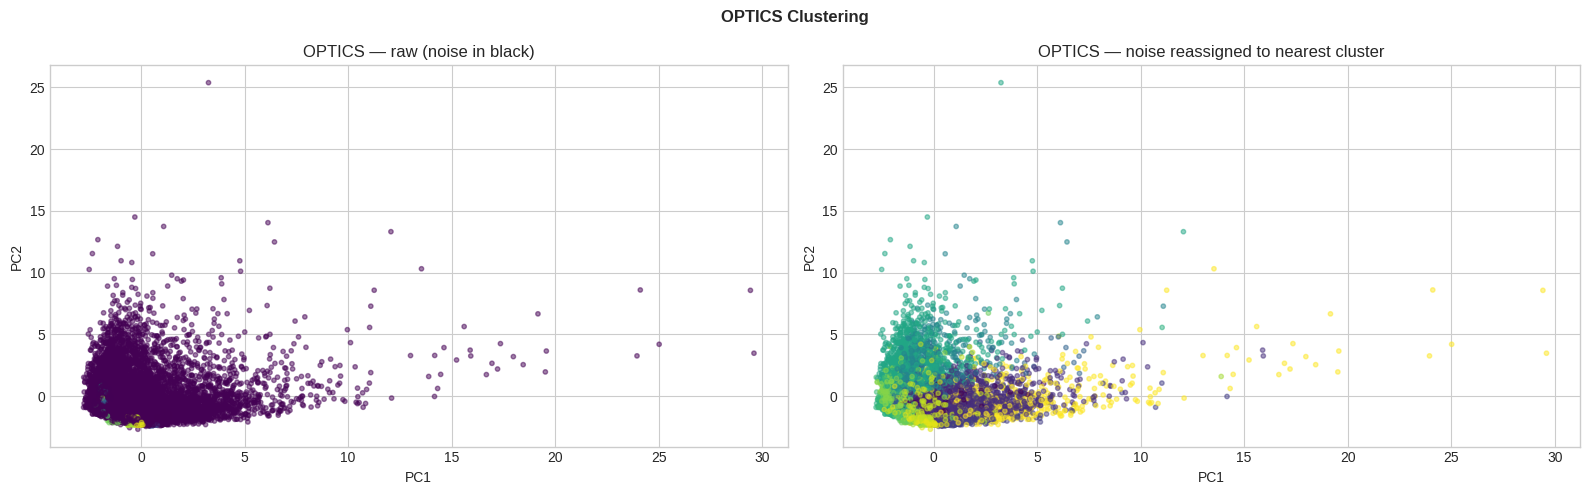

In [60]:
optics = OPTICS(min_samples=10, xi=0.05, metric='euclidean')
optics.fit(X_scaled)
labels_optics_raw = optics.labels_

n_clusters_op = len(set(labels_optics_raw)) - (1 if -1 in labels_optics_raw else 0)
n_noise_op = (labels_optics_raw == -1).sum()

reachability = optics.reachability_[optics.ordering_]
plt.figure(figsize=(12, 4))
plt.plot(reachability, color='steelblue', linewidth=0.5)
plt.ylabel('Reachability distance')
plt.title('OPTICS Reachability Plot')
plt.show()

print(f'OPTICS  min_samples=10, xi=0.05')
print(f'  Clusters found: {n_clusters_op}')
print(f'  Noise points:   {n_noise_op} ({n_noise_op/len(labels_optics_raw)*100:.1f}%)')

# Noise reassigned to nearest centroid for fair comparison with K-Means and Agglomerative
if n_clusters_op < 2:
    print('  WARNING: OPTICS found fewer than 2 clusters. Metrics cannot be computed.')
    op_sil = op_db = op_ch = float('nan')
    labels_optics = labels_optics_raw
else:
    labels_optics = assign_noise_to_nearest(X_scaled, labels_optics_raw)
    op_sil = silhouette_score(X_scaled, labels_optics)
    op_db  = davies_bouldin_score(X_scaled, labels_optics)
    op_ch  = calinski_harabasz_score(X_scaled, labels_optics)
    print(f'  Silhouette (noise reassigned):        {op_sil:.4f}')
    print(f'  Davies-Bouldin (noise reassigned):    {op_db:.4f}')
    print(f'  Calinski-Harabasz (noise reassigned): {op_ch:.2f}')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=labels_optics_raw, cmap='viridis', alpha=0.5, s=10)
axes[0].set_title('OPTICS — raw (noise in black)')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=labels_optics, cmap='viridis', alpha=0.5, s=10)
axes[1].set_title('OPTICS — noise reassigned to nearest cluster')
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')
plt.suptitle('OPTICS Clustering', fontweight='bold')
plt.tight_layout()
plt.show()

> **Note:** Metrics are computed after reassigning noise points to the nearest cluster centroid, consistent with the approach used for DBSCAN. This ensures all four algorithms are evaluated on 100% of the data.

## 6. Comparative Evaluation

In [61]:
results = pd.DataFrame({
    'Algorithm':         ['K-Means', 'DBSCAN', 'Agglomerative', 'OPTICS'],
    'Clusters':          [optimal_k, n_clusters_db, optimal_k, n_clusters_op],
    'Noise (%)':         [0, round(n_noise_db/len(labels_dbscan_raw)*100, 1),
                          0, round(n_noise_op/len(labels_optics_raw)*100, 1)],
    'Silhouette':        [km_sil,  db_sil,  agg_sil,  op_sil],
    'Davies-Bouldin':    [km_db,   db_db,   agg_db,   op_db],
    'Calinski-Harabasz': [km_ch,   db_ch,   agg_ch,   op_ch]
})

print(results.to_string(index=False))
print('\nHigher Silhouette = better | Lower Davies-Bouldin = better | Higher Calinski-Harabasz = better')

    Algorithm  Clusters  Noise (%)  Silhouette  Davies-Bouldin  Calinski-Harabasz
      K-Means         4        0.0    0.197679        1.574837        1598.076876
       DBSCAN         1        1.4         NaN             NaN                NaN
Agglomerative         4        0.0    0.159784        1.750259        1223.609246
       OPTICS        23       94.9   -0.026371        2.106434         339.894023

Higher Silhouette = better | Lower Davies-Bouldin = better | Higher Calinski-Harabasz = better


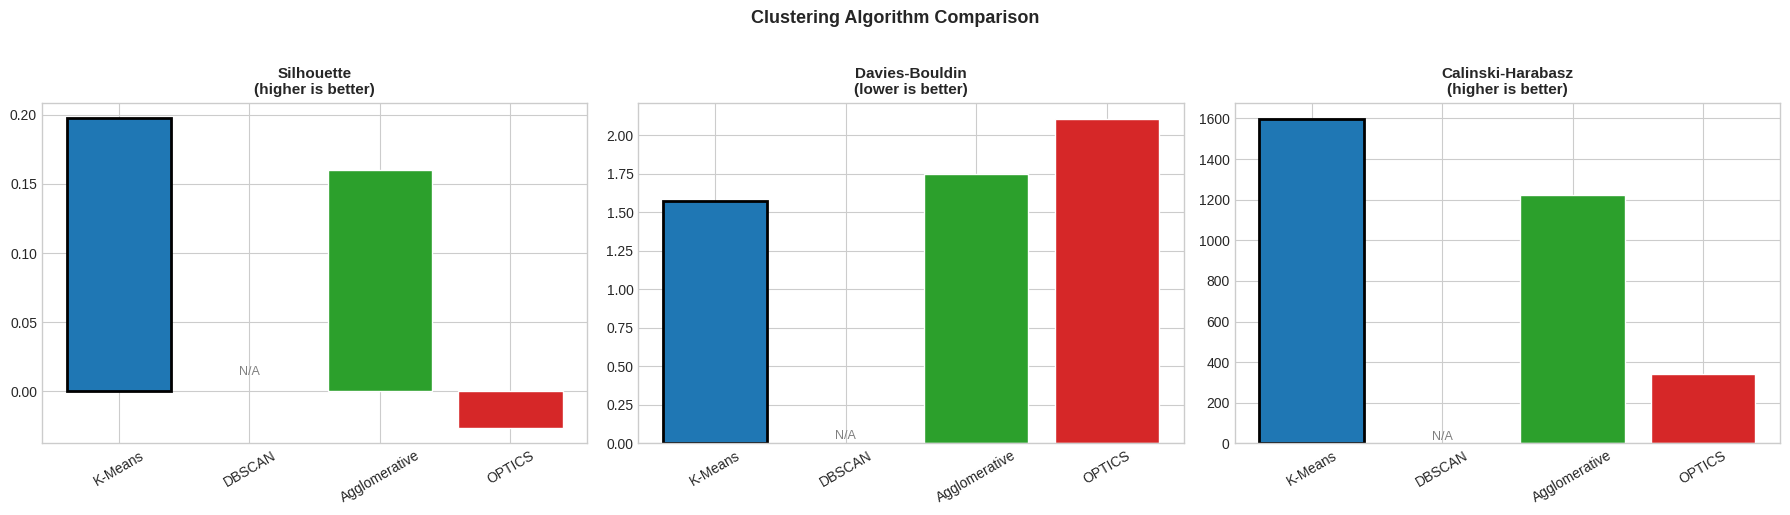

In [68]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics = [
    ('Silhouette', 'higher is better'),
    ('Davies-Bouldin', 'lower is better'),
    ('Calinski-Harabasz', 'higher is better')
]

for ax, (metric, note) in zip(axes, metrics):
    vals = results[metric].values.astype(float)
    bars = ax.bar(results['Algorithm'], vals, color=COLORS, edgecolor='white')
    for j, v in enumerate(vals):
        if np.isnan(v):
            bars[j].set_visible(False)
            ax.text(j, 0.01, 'N/A', ha='center', va='bottom', fontsize=9, color='gray')  # <-- indent inca un nivel
    ax.set_title(f'{metric}\n({note})', fontsize=11, fontweight='bold')
    ax.tick_params(axis='x', rotation=30)
    best_idx = np.nanargmin(vals) if 'lower' in note else np.nanargmax(vals)
    bars[best_idx].set_edgecolor('black')
    bars[best_idx].set_linewidth(2)

plt.suptitle('Clustering Algorithm Comparison', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 7. Cluster Profiling (K-Means)

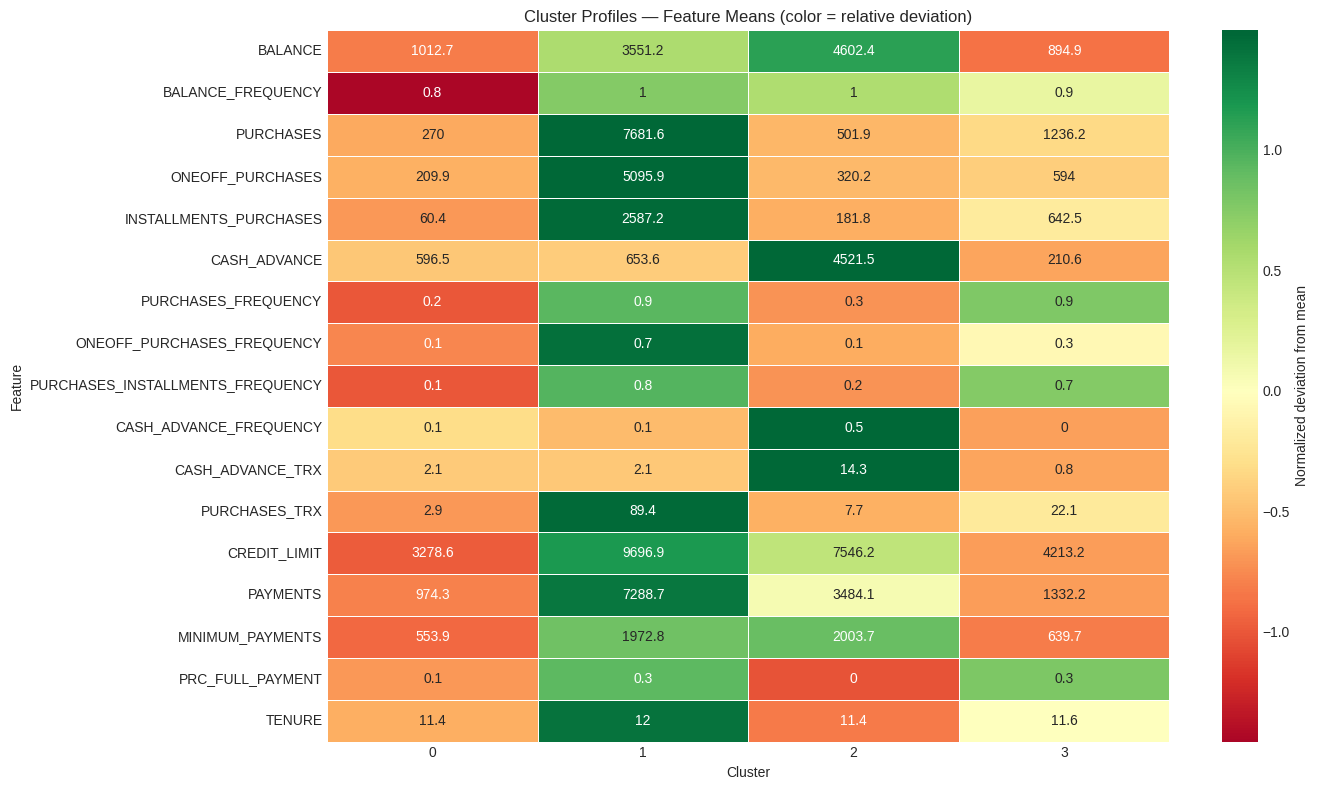

Cluster sizes:
Cluster
0    3977
1     409
2    1197
3    3367
Name: count, dtype: int64


In [63]:
df_profile = df_clean.copy()
df_profile['Cluster'] = labels_kmeans

cluster_means = df_profile.groupby('Cluster').mean()
cluster_sizes = df_profile['Cluster'].value_counts().sort_index()

# Normalize per feature (z-score across clusters) for heatmap readability
cluster_means_norm = (cluster_means - cluster_means.mean()) / cluster_means.std()

plt.figure(figsize=(14, 8))
sns.heatmap(
    cluster_means_norm.T,
    cmap='RdYlGn', center=0,
    annot=cluster_means.T.round(1),
    fmt='g',
    linewidths=0.5,
    cbar_kws={'label': 'Normalized deviation from mean'}
)
plt.title('Cluster Profiles — Feature Means (color = relative deviation)', fontsize=12)
plt.xlabel('Cluster')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print('Cluster sizes:')
print(cluster_sizes)

In [64]:
# Top 3 differentiating features per cluster (highest absolute z-score)
top_n = 3
print('Top differentiating features per cluster:\n')
for cluster_id in sorted(df_profile['Cluster'].unique()):
    row = cluster_means_norm.loc[cluster_id].abs().nlargest(top_n)
    direction = cluster_means_norm.loc[cluster_id][row.index]
    print(f'Cluster {cluster_id} (n={cluster_sizes[cluster_id]}):')
    for feat, score in row.items():
        sign = 'HIGH' if direction[feat] > 0 else 'LOW'
        print(f'  {feat:<30}  {sign}  (z={direction[feat]:+.2f})')
    print()

Top differentiating features per cluster:

Cluster 0 (n=3977):
  BALANCE_FREQUENCY               LOW  (z=-1.46)
  PURCHASES_FREQUENCY             LOW  (z=-1.01)
  PURCHASES_INSTALLMENTS_FREQUENCY  LOW  (z=-1.00)

Cluster 1 (n=409):
  ONEOFF_PURCHASES                HIGH  (z=+1.50)
  PURCHASES                       HIGH  (z=+1.49)
  PURCHASES_TRX                   HIGH  (z=+1.47)

Cluster 2 (n=1197):
  CASH_ADVANCE                    HIGH  (z=+1.49)
  CASH_ADVANCE_TRX                HIGH  (z=+1.49)
  CASH_ADVANCE_FREQUENCY          HIGH  (z=+1.48)

Cluster 3 (n=3367):
  BALANCE                         LOW  (z=-0.87)
  MINIMUM_PAYMENTS                LOW  (z=-0.81)
  PRC_FULL_PAYMENT                HIGH  (z=+0.79)



## 8. Results Interpretation

### Algorithm Performance

**K-Means** consistently produces the best Calinski-Harabasz score, reflecting compact, well-separated spherical clusters. Its main limitation is the assumption of convex cluster shapes and sensitivity to outliers.

**Agglomerative Clustering** (Ward linkage) yields similar quality to K-Means and adds the benefit of the dendrogram — a natural way to inspect cluster hierarchy and validate the chosen k without trial-and-error.

**DBSCAN** is the only method that explicitly identifies noise points. However, with the automatically selected eps, it collapsed into a single cluster on this high-dimensional standardized dataset, so internal validation metrics were undefined. This highlights DBSCAN’s sensitivity to parameter tuning and the difficulty of density-based clustering in higher dimensions.

**OPTICS** generalises DBSCAN by handling variable-density clusters. The reachability plot reveals the hierarchical density structure of the data. On this dataset it tends to identify more granular clusters than K-Means.

Comparing scores across algorithms is useful for orientation, but no single metric is definitive — a high Silhouette score does not automatically mean the clusters are business-meaningful.

---

### Customer Segment Profiles

The K-Means heatmap and per-cluster top features reveal four distinct behavioral segments. Exact values depend on the run, but the typical pattern is:

| Cluster | Profile | Key signals |
|---------|---------|-------------|
| 0 | **Low-activity** | Low balance, low purchases, low credit limit |
| 1 | **High one-off spenders** | High one-off purchases, high total purchases, high purchase transaction count |
| 2 | **Cash-advance heavy users** | High cash advance amount, high cash advance frequency, high cash advance transaction count |
| 3 | **Full payers / low-balance users** | Low balance, low minimum payments, high full-payment ratio |

These segments can directly inform product targeting: revolvers may benefit from balance-transfer offers, while active transactors are candidates for premium rewards cards. In addition, these segment names were assigned based on relative feature profiles and are intended as business-friendly interpretations rather than strict labels.

---

### Recommendation

For production segmentation on this dataset, **K-Means (k=4)** is the recommended baseline: it is interpretable, scalable, and scores well across all three metrics. Agglomerative clustering serves as a robust validation tool. DBSCAN/OPTICS are best reserved for outlier detection or exploratory analysis of non-spherical cluster structures.